<div style="
    background-color: #fff3cd; 
    border-left: 4px solid #f0ad4e; 
    padding: 10px 12px; 
    border-radius: 6px;
    color: #664d03;
">
测试环境使用cst，Jupyter环境名是cellscape_test
</div>

# 单细胞测试数据生成

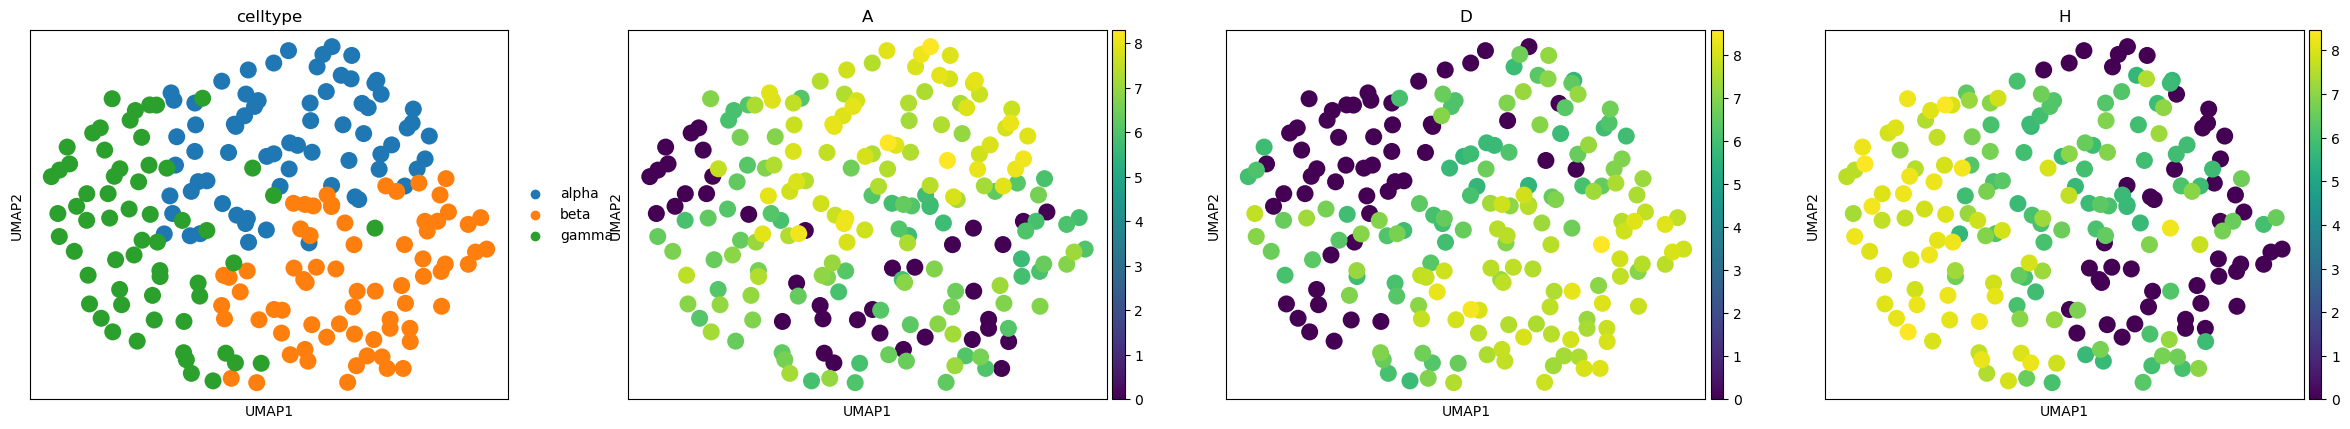

In [4]:
import os
import numpy as np
import pandas as pd
import scanpy as sc

np.random.seed(2026)

# -----------------------------
# 基因与marker定义
# -----------------------------
genes = list("ABCDEFGHIJK")

markers = {
    "alpha": ["A", "B", "C"],
    "beta":  ["D", "E", "F"],
    "gamma": ["H", "I"],
}

# 总计200个细胞
n_cells_dict = {
    "alpha": 70,
    "beta": 70,
    "gamma": 60,
}

# -----------------------------
# 构建counts表达矩阵
# -----------------------------
expr_list = []
obs_list = []

for ct, n_cells in n_cells_dict.items():
    # 背景表达
    expr = np.random.poisson(lam=1, size=(n_cells, len(genes)))
    # marker增强
    marker_idx = [genes.index(g) for g in markers[ct]]
    expr[:, marker_idx] += np.random.poisson(lam=5, size=(n_cells, len(marker_idx)))
    expr_list.append(expr)
    obs_list.extend([ct] * n_cells)

X = np.vstack(expr_list)

# -----------------------------
# AnnData
# -----------------------------
obs = pd.DataFrame({
    "celltype": obs_list
})
obs.index = [f"cell_{i}" for i in range(X.shape[0])]
var = pd.DataFrame(index=genes)
adata = sc.AnnData(
    X=X,
    obs=obs,
    var=var
)

# 保留原始counts
adata.layers["counts"] = adata.X.copy()

# 标准预处理
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.layers["lognorm"] = adata.X.copy()

# PCA / 邻接图 / UMAP
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=10)
sc.tl.umap(adata)

# 可视化
sc.pl.umap(adata, color=["celltype", "A", "D", "H"])

# 保存处理后的数据
adata.write_h5ad("example_sc_data.h5ad")

# 测试umap_highlight

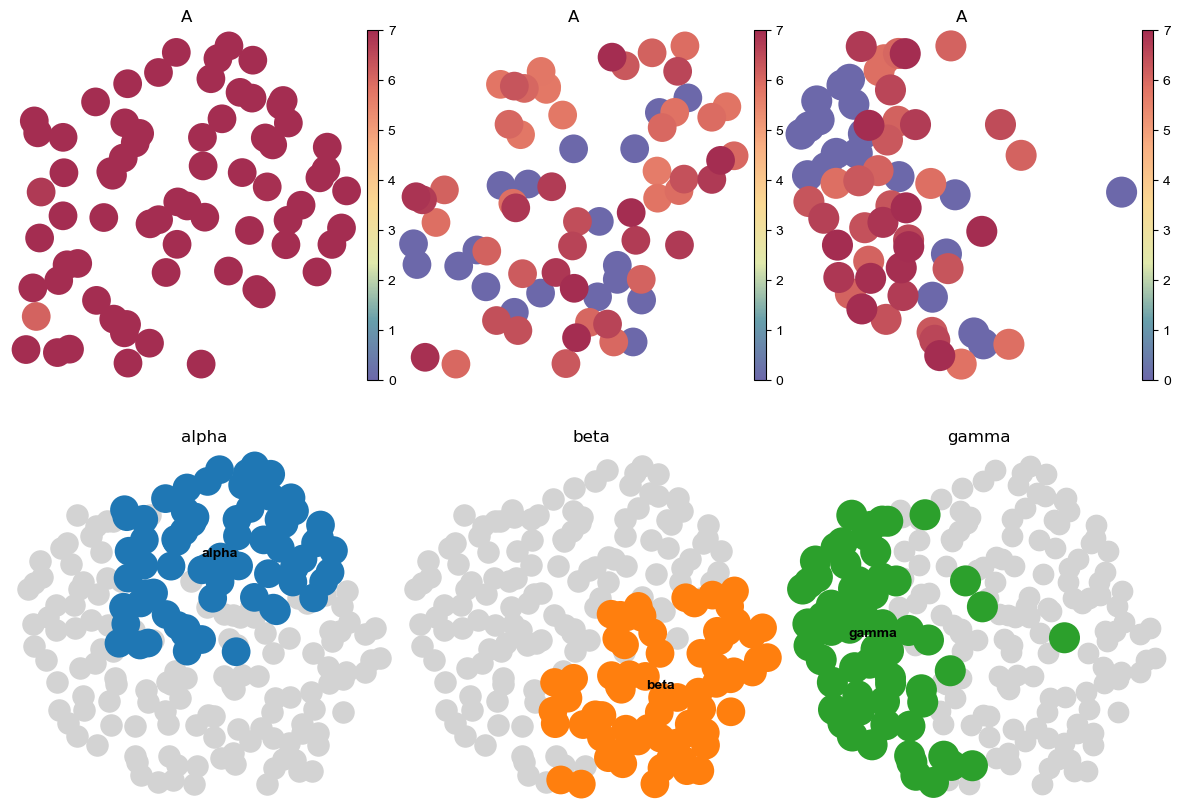

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt

import cellscape.styles as sty
import cellscape.single_cell as scp

adata = sc.read_h5ad("example_sc_data.h5ad")
fig, axes = plt.subplots(2,3, figsize=(15,10), gridspec_kw={"wspace":0})
ax = axes.flatten()

scp.umap_highlight(adata=adata, mode="gene", gene="A",
                   category_col="celltype", category_value="alpha", 
                   cmap=sty.seurat_heat(), vmax=7, vmin=0,
                   ax=ax[0],)
scp.umap_highlight(adata=adata, mode="gene", gene="A", 
                   category_col="celltype", category_value="beta",
                   cmap=sty.seurat_heat(), vmax=7, vmin=0,
                   ax=ax[1],)
scp.umap_highlight(adata=adata, mode="gene", gene="A", 
                   category_col="celltype", category_value="gamma",
                   cmap=sty.seurat_heat(), vmax=7, vmin=0,
                   ax=ax[2],)

scp.umap_highlight(adata=adata, mode="category", 
                   category_col="celltype", category_value="alpha", 
                   title="alpha", legend_loc="on data",
                   ax=ax[3])
scp.umap_highlight(adata=adata, mode="category", 
                   category_col="celltype", category_value="beta",
                   title="beta", legend_loc="on data", 
                   ax=ax[4])
scp.umap_highlight(adata=adata, mode="category", 
                   category_col="celltype", category_value="gamma",
                   title="gamma", legend_loc="on data",
                   ax=ax[5])

plt.show()

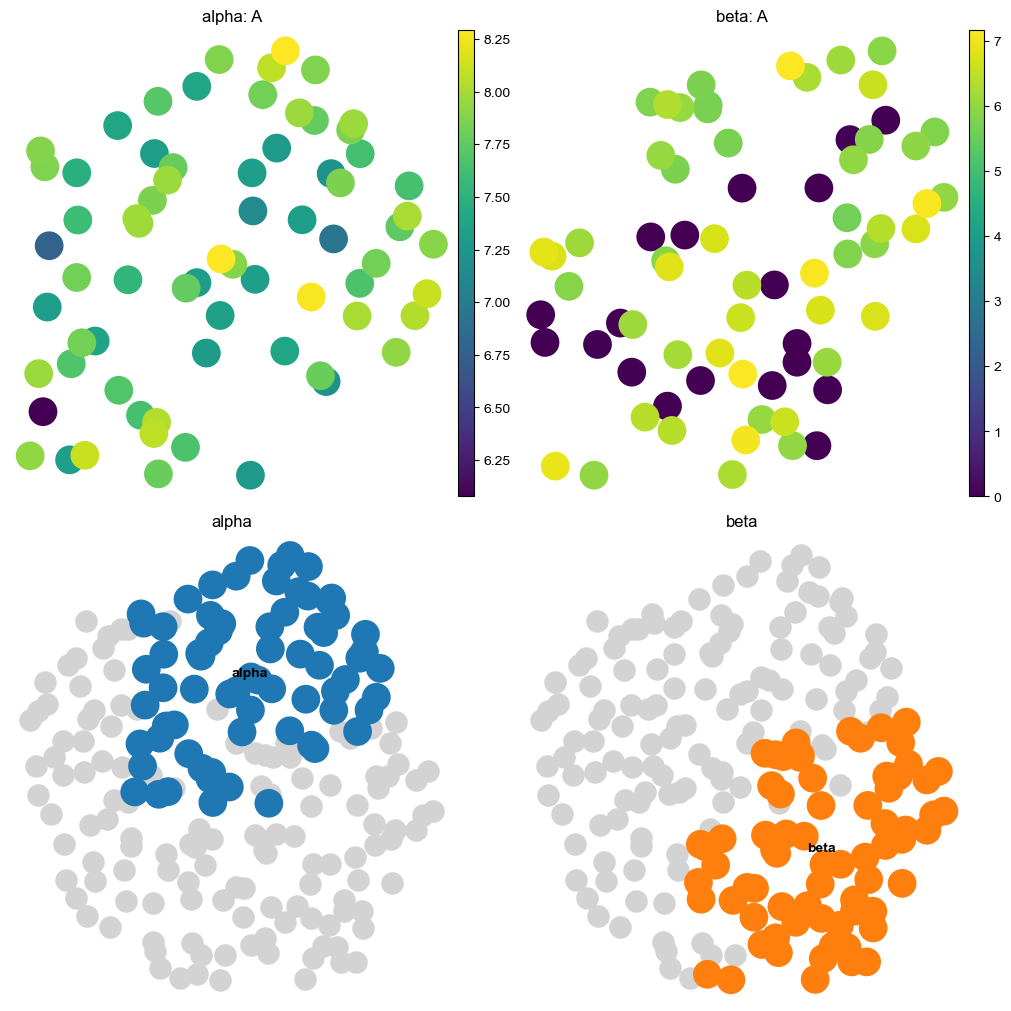

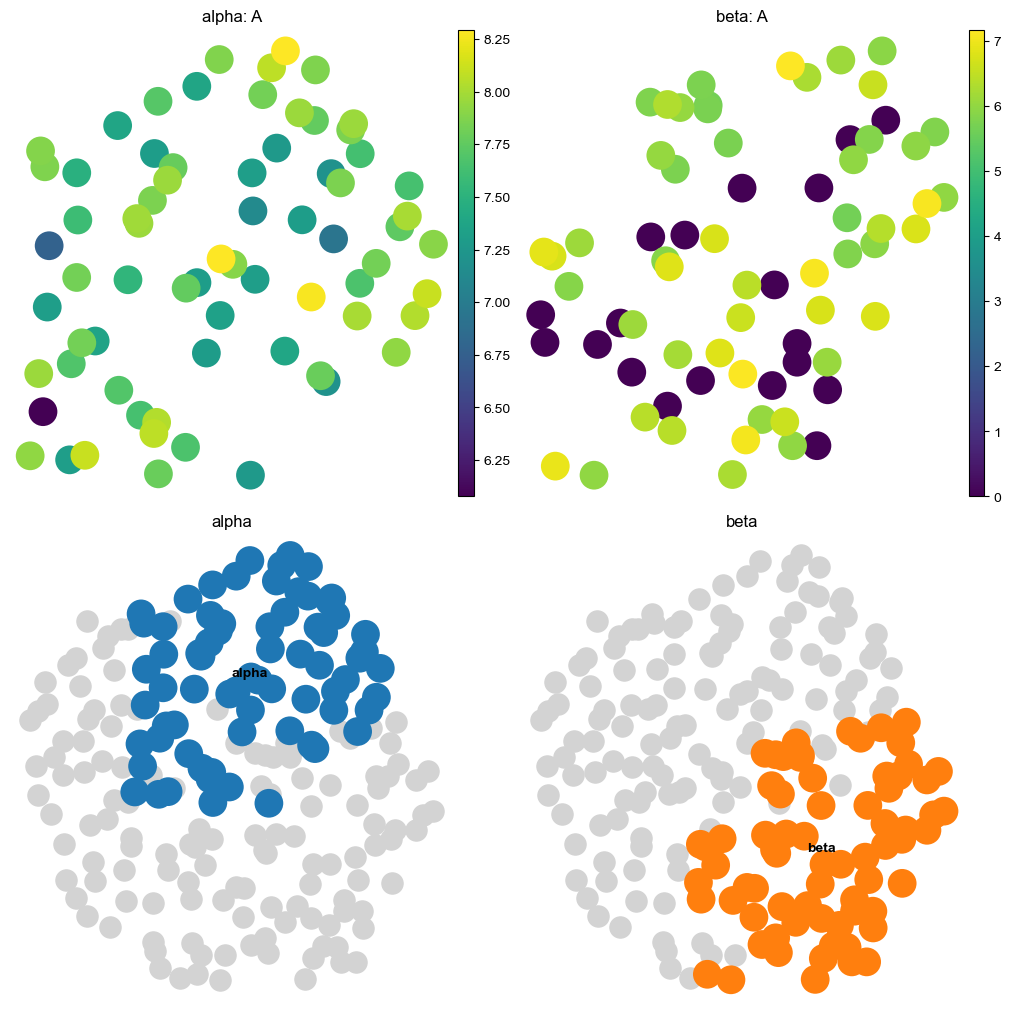

In [4]:
import scanpy as sc

import cellscape.single_cell as scp

adata = sc.read_h5ad("example_sc_data.h5ad")

scp.umap_expr_with_category(adata, 
                            category_col="celltype", category_value=["alpha", "beta"], 
                            gene="A",
                            )

In [4]:
adata

AnnData object with n_obs × n_vars = 200 × 11
    obs: 'celltype'
    uns: 'celltype_colors', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'lognorm'
    obsp: 'connectivities', 'distances'